In [ ]:
#https://towardsdatascience.com/most-effective-way-to-implement-radial-basis-function-neural-network-for-classification-problem-33c467803319

import numpy as np

def get_distance(x1, x2):
    sum = 0
    for i in range(len(x1)):
        sum += (x1[i] - x2[i]) ** 2
    return np.sqrt(sum)

def kmeans(X, k, max_iters, randomSeed):
    np.random.seed(randomSeed)
    centroids = X[np.random.choice(range(len(X)), k, replace=False)]
    converged = False
    current_iter = 0
    while (not converged) and (current_iter < max_iters):
        cluster_list = [[] for i in range(len(centroids))]

        for x in X:  # Go through each data point
            distances_list = []
            for c in centroids:
                distances_list.append(get_distance(c, x))
            cluster_list[int(np.argmin(distances_list))].append(x)

        cluster_list = list((filter(None, cluster_list)))
        prev_centroids = centroids.copy()
        centroids = []

        for j in range(len(cluster_list)):
            centroids.append(np.mean(cluster_list[j], axis=0))

        pattern = np.abs(np.sum(prev_centroids) - np.sum(centroids))
        print('K-MEANS: ', int(pattern))
        converged = (pattern == 0)
        current_iter += 1

    return np.array(centroids), [np.std(x) for x in cluster_list]

In [ ]:
class RBF:

    def __init__(self, X, y, tX, ty, num_of_classes,
                 k, std_from_clusters=True, randomSeed = 0):
        self.X = X
        self.y = y

        self.tX = tX
        self.ty = ty

        self.number_of_classes = num_of_classes
        self.k = k
        self.std_from_clusters = std_from_clusters
        self.randomSeed = randomSeed

    def convert_to_one_hot(self, x, num_of_classes):
        arr = np.zeros((len(x), num_of_classes))
        for i in range(len(x)):
            c = int(x[i])
            arr[i][c] = 1
        return arr

    def rbf(self, x, c, s):
        distance = get_distance(x, c)
        return 1 / np.exp(-distance / s ** 2)

    def rbf_list(self, X, centroids, std_list):
        RBF_list = []
        for x in X:
            RBF_list.append([self.rbf(x, c, s) for (c, s) in zip(centroids, std_list)])
        return np.array(RBF_list)

    def fit(self):
        self.centroids, self.std_list = kmeans(self.X, self.k, max_iters=1000, randomSeed = self.randomSeed)
        if not self.std_from_clusters:
            dMax = np.max([get_distance(c1, c2) for c1 in self.centroids for c2 in self.centroids])
            self.std_list = np.repeat(dMax / np.sqrt(2 * self.k), self.k)

        RBF_X = self.rbf_list(self.X, self.centroids, self.std_list)
        self.w = np.linalg.pinv(RBF_X.T @ RBF_X) @ RBF_X.T @ self.convert_to_one_hot(self.y, self.number_of_classes)
        RBF_list_tst = self.rbf_list(self.tX, self.centroids, self.std_list)
        self.pred_ty = RBF_list_tst @ self.w
        self.pred_ty = np.array([np.argmax(x) for x in self.pred_ty])

        return self.pred_ty
        #diff = self.pred_ty - self.ty
        #print('Accuracy: ', len(np.where(diff == 0)[0]) / len(diff))

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive',  force_remount=True)
data = pd.read_excel('/content/drive/My Drive/OrginalAQTehran.xlsx')

data.drop('Time',axis=1,inplace=True)
def probThreshold(inpProb):
    if inpProb  <  51:
        return(0)
    if 50<inpProb < 101:
        return(1)
    if 100<inpProb<151:
        return(2)
    if 150<inpProb<201:
        return(3)
    if 200<inpProb<301:
        return(4)
    else:
        return(5)

data['Outcomes']=data['AQI'].apply(probThreshold)

X=data.iloc[:,:-2].values
y=data.iloc[:,-1].values

Mounted at /content/drive


In [ ]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y,test_size=.15, random_state =12)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=.176, random_state=12) #0.176 * 0.85 = 0.15

unique, counts = np.unique(y_train, return_counts=True)
print("TrainSet (class: count) = ", dict(zip(unique, counts)), "TestSize : ", y_train.shape[0])

unique, counts = np.unique(y_test, return_counts=True)
print("TestSet (class: count) =", dict(zip(unique, counts)), "TestSize : ", y_test.shape[0])

unique, counts = np.unique(y_val, return_counts=True)
print("ValSet (class: count) = ", dict(zip(unique, counts)), "ValSize : ", y_val.shape[0])

print(y.shape[0], " = ", (y_train.shape[0] + y_test.shape[0] + y_val.shape[0]))

TrainSet (class: count) =  {0: 54, 1: 835, 2: 339, 3: 48, 4: 1, 5: 1} TestSize :  1278
TestSet (class: count) = {0: 12, 1: 185, 2: 70, 3: 7, 5: 1} TestSize :  275
ValSet (class: count) =  {0: 13, 1: 176, 2: 78, 3: 6, 4: 1} ValSize :  274
1827  =  1827


In [ ]:
#for i in range(450, 550, 10):
RBF_CLASSIFIER = RBF(X_train, y_train, X_test, y_test, num_of_classes=6,
                    k=700, std_from_clusters=False, randomSeed = 0)#k=500 (seed = 0, k =177)

y_pred = RBF_CLASSIFIER.fit()
print(i)
print(accuracy_score(y_test, y_pred))
#0.9454545454545454 400, 0
#0.9490909090909091 600, 0
#0.9527272727272728 700, 0
#0.9490909090909091 370, 12
#0.9490909090909091 470, 2

K-MEANS:  493
K-MEANS:  41
K-MEANS:  69
K-MEANS:  6
K-MEANS:  0
540
0.9527272727272728


0.9527272727272728
0.8083140283140283
0.8626125874125876
              precision    recall  f1-score   support

           0       1.00      0.67      0.80        12
           1       0.96      0.99      0.98       185
           2       0.92      0.96      0.94        70
           3       1.00      0.43      0.60         7
           5       1.00      1.00      1.00         1

    accuracy                           0.95       275
   macro avg       0.98      0.81      0.86       275
weighted avg       0.95      0.95      0.95       275



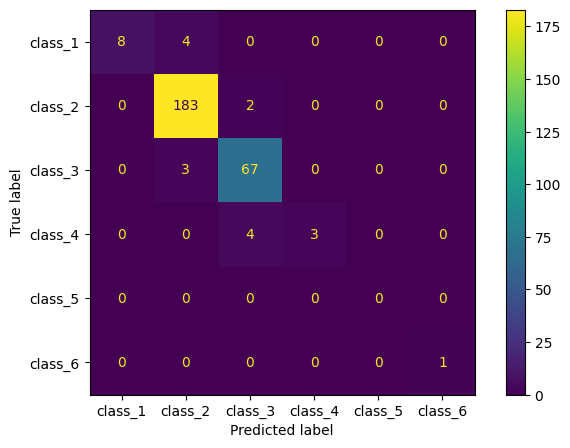

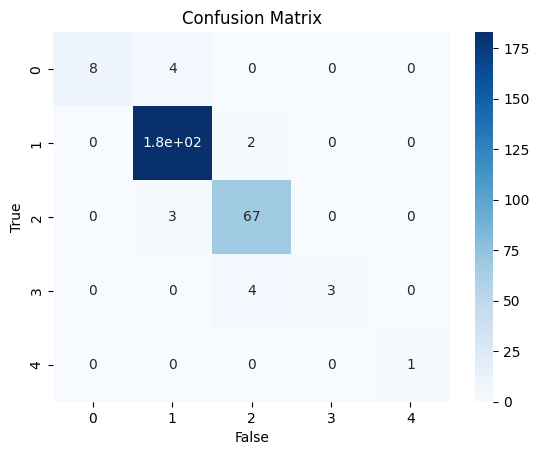

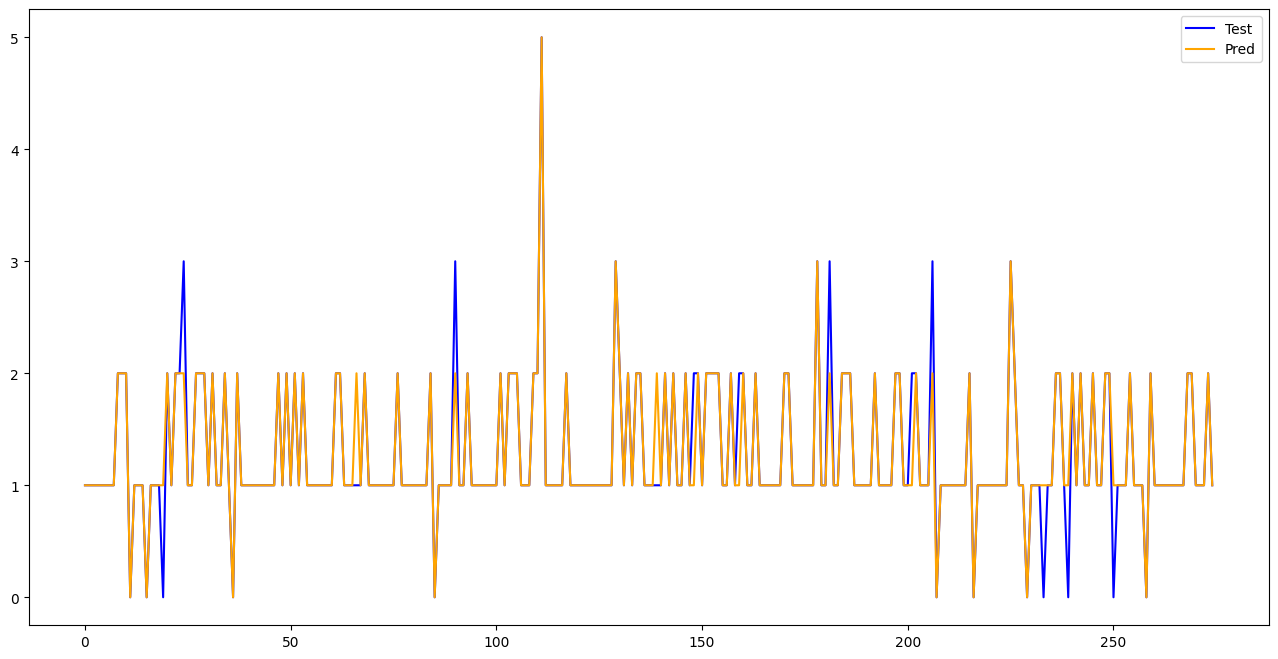

In [ ]:
from sklearn.metrics import classification_report,accuracy_score,balanced_accuracy_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print(accuracy_score(y_test, y_pred))
print(balanced_accuracy_score(y_test,y_pred))
print(f1_score(y_test,y_pred,average='macro'))
print(classification_report(y_test, y_pred))
# dot_data = tree.export_graphviz(models, out_file=None, filled=True, rounded=True)
# graph = pydotplus.graph_from_dot_data(dot_data)
# display(Image(data=graph.create_png()))
fig, ax = plt.subplots(figsize=(8, 5))
cmp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3, 4, 5]), display_labels=["class_1", "class_2", "class_3","class_4","class_5","class_6"],)
cmp.plot(ax=ax)
plt.show()
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot = True, cmap= 'Blues')
plt.ylabel('True')
plt.xlabel('False')
plt.title('Confusion Matrix')
plt.show()
plt.figure(figsize=(16,8))
plt.plot(y_test, color='blue', label='Test')
plt.plot(y_pred, color='orange', label='Pred')
plt.legend()
plt.show()